<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11166 entries, 0 to 11165
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    11166 non-null  object 
 1   id_artist             11166 non-null  object 
 2   name_artist           11166 non-null  object 
 3   full_title            11166 non-null  object 
 4   title                 11166 non-null  object 
 5   featured_artists      3517 non-null   object 
 6   primary_artist        11166 non-null  object 
 7   language              11061 non-null  object 
 8   album                 9652 non-null   object 
 9   stats_pageviews       4642 non-null   float64
 10  swear_IT              11166 non-null  int64  
 11  swear_EN              11166 non-null  int64  
 12  swear_IT_words        11166 non-null  object 
 13  swear_EN_words        11166 non-null  object 
 14  year                  10951 non-null  object 
 15  month              

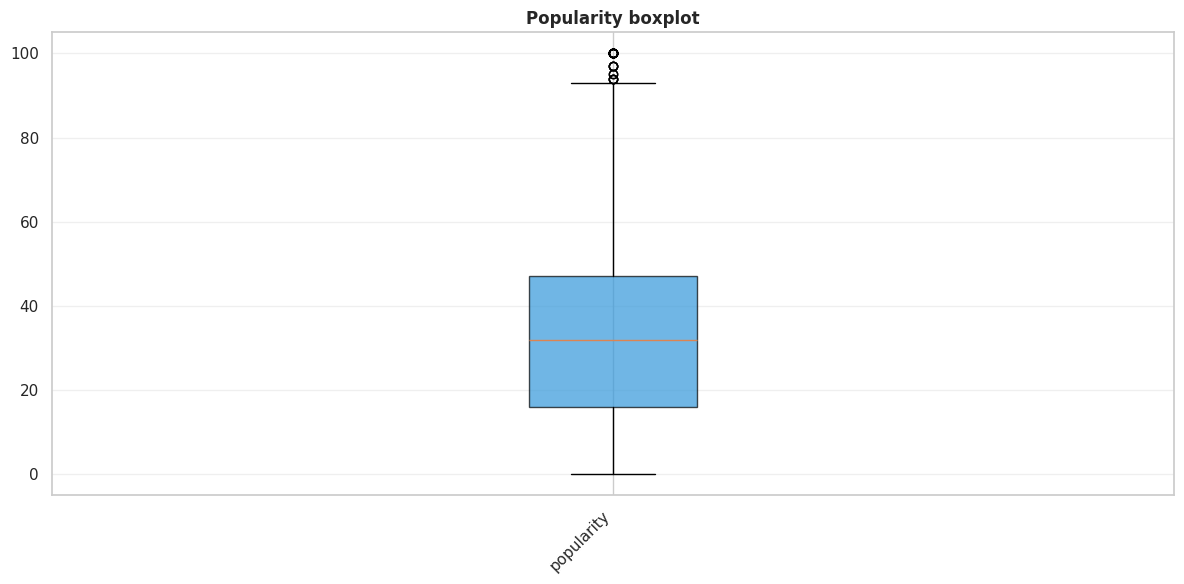

Quartile Stats
Column popularity:
  Min value: 0.00
  Q1 (25%): 16.00
  Q2 (50%): 32.00
  Q3 (75%): 47.00
  Max value: 100.00
  IQR (Q3-Q1): 31.00


Songs with year > 2025: 241
Songs with year < 1930: 84

Original tracks count: 11164
Dropped tracks count:  10596
Dropped tracks:        568
Flatness filter. Dropping:
Tracks with invalid flatness: 0


In [ ]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
from pathlib import Path

# Add parent directory to path for importing local modules
current_dir = Path.cwd()
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

from utils.plotting import *

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# We import casted datasets to start data preparation
tracks = pd.read_csv("../enriched_datasets/tracks_enriched.csv", sep=',')
artists = pd.read_csv("../enriched_datasets/artists.csv", sep=',')

# Remove duplicate (id, artist) pairs
tracks.info()
artists.info()

# we need to cast back the values after importing the csv from disk
columns_to_string   = ["id_author", "name", "gender", "birth_place", "nationality", "description", "province", "region", "country", "source"]
for column in columns_to_string:
    artists[column] = artists[column].astype('string')
    
columns_to_datetime = ["birth_date", "active_start", "active_end"]
for column in columns_to_datetime:
    artists[column] = pd.to_datetime(artists[column], errors='coerce')

artists.info()


columns_to_string   = ["id", "id_artist", "name_artist", "full_title", "title", "featured_artists", "primary_artist", "language", "album", "album_name", "album_type", "lyrics", "album_image", "id_album"]
for column in columns_to_string:
    tracks[column] = tracks[column].astype('string')
    
# these columns are array of strings, let's leave them as objects
columns_to_array = ["swear_IT_words", "swear_EN_words"]

# to datetime
tracks['album_release_date'] = pd.to_datetime(tracks['album_release_date'], errors='coerce')
tracks['popularity'] = tracks['popularity'].apply(pd.to_numeric, errors='coerce')
tracks['popularity'] = tracks['popularity'].astype('Int64')

# from df.info we can see that this column is a boolean, so let's cast it to bool
tracks['explicit'] = tracks['explicit'].astype('bool')

# different values, like NaN or 2021.0 so cast to int
tracks['year'] = tracks['year'].apply(pd.to_numeric, errors='coerce')
tracks["year"] = tracks['year'].astype('Int64') 

tracks.info()
###############################################################################################
# Remove duplicates
# we can see duplicate IDs for different tracks
duplicates = tracks[tracks['id'].duplicated()].drop('id', axis=1)

# we can drop rows 4538 and 4558 from the original tracks dataframe
tracks[tracks.duplicated(subset=['full_title'])]
len(tracks)
tracks.drop_duplicates(subset=['full_title'], keep='first', inplace=True)
len(tracks)
# by checking again we can see that we do not have duplicate titles
tracks[tracks.duplicated(subset=['full_title'])]

# Drop id, id_artist, album_id and album image as they are not useful
tracks.drop(['id', 'id_artist', 'album_image', 'id_album'], axis=1, inplace=True)

artists.head()
artists.drop(['id_author','source'], axis=1, inplace=True)

###############################################################################################
# Gender analysis
# We check if an artist is a group or band, we first check gender == Nan
artists[artists['gender'].isnull()]
# we can see that gender in this case does not make sense as it is a group who could be made by male or female
# all groups are made by males except 99 posse who also has a female member

# we assign male gender to all except 99 posse. We could also assign male as it is 2/3 males
artists['gender'].unique()

# get all rows where gender is null and artist name != 99 posse
mask = (artists['gender'].isnull()) & (artists['name'] != '99 posse')
# assign 'M' to masked rows
artists.loc[mask, 'gender'] = 'M'

# we can see that the casting was successful
artists[artists['gender'].isnull()]

###############################################################################################
# we can verify that this worked effectively from the boxplot with correct min value == 0 and max value == 100
plot_boxplot(tracks, ["popularity"], "Popularity boxplot")
###############################################################################################
# we also remove songs with year > 2025 as this is not possible
print(f"Songs with year > 2025: {len(tracks[tracks['year'] > 2025])}")
print(f"Songs with year < 1930: {len(tracks[tracks['year'] < 1930])}\n")

# keep valid row
original_tracks_length = len(tracks)
tracks = tracks[(tracks['year'] <= 2025) & (tracks['year'] > 1930)]
dropped_tracks_length = len(tracks)
print(f"Original tracks count: {original_tracks_length}")
print(f"Dropped tracks count:  {dropped_tracks_length}")
print(f"Dropped tracks:        {original_tracks_length - dropped_tracks_length}")

###############################################################################################
# keep valid row
print("Flatness filter. Dropping:")
invalid_flatness = tracks[(tracks['flatness'] < 0) | (tracks['flatness'] > 1)]
print(f"Tracks with invalid flatness: {len(invalid_flatness)}")

###############################################################################################
# Featured artist if nan can be casted to empty string as no artist is featured
tracks[tracks['featured_artists'].isnull()]
mask = tracks['featured_artists'].isnull()
# assign '' to masked rows
tracks.loc[mask, 'featured_artists'] = ''
tracks[tracks['featured_artists'].isnull()]
###############################################################################################


tracks[tracks['name_artist'] != tracks['primary_artist']]
###############################################################################################
# null albums, we do not care about album name as it will not be part of the clustering
tracks[tracks['album'].isnull()]


###############################################################################################
# drop Useless columns

tracks_columns = list(tracks.columns)


###############################################################################################
# export to csv

tracks.to_csv('../prepared_datasets/tracks.csv', index=False)
artists.to_csv('../prepared_datasets/aritsts.csv', index=False)